# RS Latches and Flip-Flops

## Import and Formatting

The goal of this section is to import all the necessary files and libraries required for the subsequent data analysis.  
It also includes setting up the formatting parameters for the plots and visualizations.

### Import

In [1]:
# ----  Standard import
import matplotlib.pyplot as plt
import numpy as np

# ----- Spice import
from PySpice.Spice.Netlist import Circuit, SubCircuit
from PySpice.Unit import *

### Formatting

Adjusting Plotly chart settings for clarity and consistency.

In [2]:
# ----  Formatting charts
%matplotlib inline
from IPython.core.pylabtools import figsize
import matplotlib as mpl
mpl.rcParams['figure.figsize']  = (12, 7)
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.edgecolor']  = "#bcbcbc"
mpl.rcParams['axes.grid']       = True
mpl.rcParams['axes.facecolor']  = "#eeeeee"
mpl.rcParams['axes.labelsize']  = "large"
mpl.rcParams['axes.titlesize']  = "x-large"
mpl.rcParams['patch.linewidth'] = 0.5
mpl.rcParams['patch.edgecolor'] = "#eeeeee"
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['grid.linestyle']  = "--"

## Introduction

The **RS latch** is the simplest memory element used to store a single bit of information. As shown in [](#RS_representation_classique), it consists of two inputs and two outputs. The inputs are labeled *S* (**Set**) and *R* (**Reset**). The outputs are denoted by *Q* and $\bar{Q}$, where $\bar{Q}$ is always the logical complement of $Q$.

```{figure} ./images/RS_classique.svg
:name: RS_representation_classique
:align: center
:width: 300px

Symbolic representation of an RS latch
```

As illustrated in [](#RS_representation_bascule_synchrone_asynchrone), there are two main types of RS memory elements: **asynchronous RS latches** and **synchronous RS latches**.

```{note} Asynchronous vs. synchronous
An asynchronous RS latch changes its output state immediately when its input signals change.  
In contrast, a synchronous RS latch updates its output only when a clock signal is active (or, depending on the implementation, on a specific clock edge such as the rising or falling edge).
```

```{figure} ./images/RS_asynchrone.svg
:name: RS_representation_bascule_synchrone_asynchrone
:align: center
:width: 400px

Symbolic representation of an asynchronous RS latch versus a synchronous RS latch
```

## Operating Principle

The values of the outputs $Q$ and $\bar{Q}$ depend on the input signals $S$ and $R$.

* When $S = 1$, the latch is **set**: the outputs become $Q = 1$ and $\bar{Q} = 0$.
* When $R = 1$, the latch is **reset**: the outputs become $Q = 0$ and $\bar{Q} = 1$.
* When $S = 0$ and $R = 0$, the latch **stores the previous state**:
  $Q_n = Q_{n-1}$ and $\bar{Q}*n = \bar{Q}*{n-1}$.
* When $S = 1$ and $R = 1$, this configuration is **forbidden**, as it leads to an undefined or unstable behavior.

The truth table summarizing the possible configurations is given in [](#Table_de_verite_d_une_bascule_RS).

```{table} Truth table of an RS latch
:name: Table_de_verite_d_une_bascule_RS
:align: center

| $S$ | $R$ |     $Q$      |     $\bar{Q}$   |
| --- | --- | ------------ | --------------- |
|  0  |  0  |  $Q_{n-1}$   | $\bar{Q}_{n-1}$ |
|  0  |  1  |       0      |        1        |
|  1  |  0  |       1      |        0        |
|  1  |  1  |  undefined   |    undefined    |
```

In the remainder of this study, the objective is to analyze **synchronous and asynchronous RS latches** from an electronic perspective, extending the discussion down to **transistor-level design**.

The timing diagram of an asynchronous RS latch is illustrated in [](#RS_chronograme).

```{figure} ./images/RS_chronograme.svg
:name: RS_chronograme
:align: center
:width: 200px

Timing diagram of an RS latch
```

```{warning}
For the RS flip-flop, the truth table is very similar to that of the RS latch, with a few differences.  
First, the forbidden condition occurs when $H = 1$, $S = 1$, and $R = 1$. If any one of these signals is equal to 0, the circuit operates normally.  

Another important point is that the output changes only when the clock signal $H$ is active (or, depending on the implementation, during the clock transition).  

The [](#Table_de_verite_d_une_bascule_RS_synchrone) presents the corresponding truth table.

```{table} Truth table of an RS flip-flop
:name: Table_de_verite_d_une_bascule_RS_synchrone
:align: center

| $H$ | $S$ | $R$ |     $Q$      |     $\bar{Q}$   |
| --- | --- | --- | ------------ | --------------- |
|  0  |  X  |  X  |  $Q_{n-1}$   | $\bar{Q}_{n-1}$ |
|  X  |  0  |  0  |  $Q_{n-1}$   | $\bar{Q}_{n-1}$ |
|  1  |  1  |  0  |       1      |        0        |
|  1  |  0  |  1  |       0      |        1        |
|  1  |  1  |  1  |  undefined   |    undefined    |
```

## RS Latch Implementation Using Logic Gates

There are two types of RS latches: **synchronous RS latches** and **asynchronous RS latches**.
The objective of this section is to study both types, highlighting their **differences** as well as their **common characteristics**.

Before starting, it is important to note that there are **many possible electronic implementations** of an RS latch. Some designs offer better performance than others in terms of speed, power consumption, or robustness. The final choice of implementation depends entirely on the **design specifications** and the **operating environment** in which the circuit is intended to function.

### Asynchronous RS Latch

#### Circuit Visualization (NAND Gates & NOR Gates)

Figure [](#RS_asynchrone_porte_logique) illustrates the construction of an asynchronous RS latch using **NAND gates** and **NOR gates**.
In both cases, the circuit is conceptually simple: it consists of two identical logic gates (either two NAND gates or two NOR gates). One input of each gate is connected to the control signals *R* and *S*, while the output of each gate is fed back to the input of the other gate, creating a cross-coupled structure.

```{figure} ./images/RS_asynchrone_porte_logique.svg
:name: RS_asynchrone_porte_logique
:align: center
:width: 400px

Different logic-gate implementations of an asynchronous RS latch
```

```{attention}
Although the two circuits are structurally very similar, their behavior differs due to the nature of the logic gates used.

With NOR gates, the output behavior directly follows the logical definition of the RS latch.  
With NAND gates, however, the signals are inverted. As a result, the forbidden condition is no longer $R = 1$ and $S = 1$, but instead $R = 0$ and $S = 0$.

Furthermore, in NAND-based RS latches, the inputs are typically considered **active-low**, meaning that the latch responds when the input transitions to a low logic level rather than a high one.
```

The objective of the next section is to analyze whether these two implementations exhibit meaningful differences by studying their behavior through simulation.

#### Simulation (NAND Gates)

In [3]:
class NAND(SubCircuit):
    """
    CMOS NAND Gate Subcircuit Implementation

    Description
    -----------
    This class implements a 2-input CMOS NAND gate using complementary
    MOSFET transistors based on standard CMOS logic design.

    Logic function
    --------------
        Y = NOT(A AND B)

    Architecture
    ------------
    - Pull-Up Network (PUN):  PMOS transistors in parallel
    - Pull-Down Network (PDN): NMOS transistors in series

    External Nodes
    --------------
    A   : Input A
    B   : Input B
    Y   : Output
    VDD : Power supply
    """

    # Define the external connection nodes of the subcircuit
    __nodes__ = ('A', 'B', 'Y', 'VDD')

    def __init__(self, name):
        """
        Initialize the NAND gate subcircuit.

        Parameters
        ----------
        name : str
            Unique name of the subcircuit instance
        """
        
        # Initialize parent SubCircuit class with defined nodes
        super().__init__(name, *self.__nodes__)

        # ============================================================
        # Internal Node Declaration
        # ============================================================
        # Intermediate node used to connect NMOS transistors in series
        intermediate_node = 'inter'

        # ============================================================
        # Pull-Up Network (PUN) - PMOS Transistors
        # ============================================================
        # Function:
        # Provides a path from VDD to output when any input is LOW.
        #
        # Configuration:
        # Parallel PMOS transistors implement the NAND logic behavior.
        #
        # Electrical behavior:
        # PMOS conducts when Gate = LOW
        #

        # PMOS transistor controlled by input A
        self.MOSFET(
            1,                      # Instance ID
            'Y',                    # Drain
            'A',                    # Gate
            'VDD',                  # Source
            'VDD',                  # Bulk (connected to VDD for PMOS)
            model='ptm65nm_pmos',  # PMOS model
            l=0.35 @ u_um,         # Channel length
            w=0.5 @ u_um           # Channel width
        )

        # PMOS transistor controlled by input B
        self.MOSFET(
            2,
            'Y',
            'B',
            'VDD',
            'VDD',
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5 @ u_um
        )
        
        # ============================================================
        # Pull-Down Network (PDN) - NMOS Transistors
        # ============================================================
        # Function:
        # Provides a path from output to ground when BOTH inputs are HIGH.
        #
        # Configuration:
        # Series NMOS transistors implement the NAND logic behavior.
        #
        # Electrical behavior:
        # NMOS conducts when Gate = HIGH
        #

        # First NMOS transistor controlled by input A
        self.MOSFET(
            3,
            'Y',                      # Drain connected to output
            'A',                      # Gate controlled by input A
            intermediate_node,       # Source connected to intermediate node
            circuit.gnd,             # Bulk connected to ground
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.1 @ u_um
        )

        # Second NMOS transistor controlled by input B
        self.MOSFET(
            4,
            intermediate_node,       # Drain connected to intermediate node
            'B',                      # Gate controlled by input B
            circuit.gnd,             # Source connected to ground
            circuit.gnd,             # Bulk connected to ground
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.1 @ u_um
        )

In [4]:
class RS_NAND(SubCircuit):
    """
    RS Latch implemented using cross-coupled NAND gates

    Description
    -----------
    This subcircuit implements a basic RS (Reset-Set) latch using two
    cross-coupled CMOS NAND gates. This is a fundamental sequential logic
    element capable of storing one bit of information.

    Logic behavior (active LOW inputs)
    ----------------------------------
    R = 0, S = 1  -> Reset state  -> Q = 0, Q_bar = 1
    R = 1, S = 0  -> Set state    -> Q = 1, Q_bar = 0
    R = 1, S = 1  -> Hold state   -> Q retains previous value
    R = 0, S = 0  -> Invalid state (forbidden condition)

    Architecture
    ------------
    - Two NAND gates connected in cross-coupled feedback configuration
    - Output of each gate feeds one input of the opposite gate
    - Creates bistable memory element

    External Nodes
    --------------
    R      : Reset input (active LOW)
    S      : Set input (active LOW)
    Q      : Primary output
    Q_bar  : Complementary output
    VDD    : Power supply
    """

    # External nodes definition for subcircuit interface
    __nodes__ = ('R', 'S', 'Q', 'Q_bar', 'VDD')

    def __init__(self, name: str):
        """
        Initialize the RS latch using NAND gates.

        Parameters
        ----------
        name : str
            Unique identifier for the subcircuit instance
        """

        # Initialize parent SubCircuit with defined external nodes
        super().__init__(name, *self.__nodes__)
        
        # ============================================================
        # Cross-Coupled NAND Gate Implementation
        # ============================================================
        # Principle:
        # Each NAND gate output feeds back into the other NAND gate input.
        #
        # This feedback loop creates a bistable circuit capable of storing
        # one bit of digital information.
        #

        # ------------------------------------------------------------
        # NAND Gate L1
        # ------------------------------------------------------------
        # Inputs:
        #   - Reset input (R)
        #   - Feedback from Q
        #
        # Output:
        #   - Generates Q_bar
        #
        # Function:
        # Controls the complementary output based on reset signal
        #
        self.X(
            'L1',        # Instance name
            'NAND',      # Subcircuit reference
            'R',         # Input: Reset
            'Q',         # Input: Feedback from Q
            'Q_bar',     # Output: Complementary output
            'VDD'        # Power supply
        )

        # ------------------------------------------------------------
        # NAND Gate L2
        # ------------------------------------------------------------
        # Inputs:
        #   - Set input (S)
        #   - Feedback from Q_bar
        #
        # Output:
        #   - Generates Q
        #
        # Function:
        # Controls the main output based on set signal
        #
        self.X(
            'L2',        # Instance name
            'NAND',      # Subcircuit reference
            'S',         # Input: Set
            'Q_bar',     # Input: Feedback from Q_bar
            'Q',         # Output: Main output
            'VDD'        # Power supply
        )

Maintenant que le circuit est parfaitement implémenter avec Spice avec des portes NAND, la prochaine étape eest de visualiser le résultat afin d'avoir une vision global et vérifier si les résultats attendus, mais aussi les temps de monté de chaque composant.

In [5]:
# ============================================================
# CMOS RS Latch Simulation using NAND Gates
# Technology: PTM 65 nm Bulk CMOS
#
# Description:
# This simulation evaluates the dynamic behavior of an RS latch
# implemented using CMOS NAND gates at transistor level.
#
# The simulation includes:
#   - PTM 65nm transistor models
#   - CMOS NAND gate subcircuit
#   - Cross-coupled RS latch implementation
#   - Transient analysis with realistic input waveforms
#
# Objective:
#   Verify correct bistable operation, switching behavior,
#   and memory functionality of the RS latch.
# ============================================================

# ============================================================
# Circuit Creation
# ============================================================
# Create a new circuit instance
# Each simulation should use its own isolated circuit definition
circuit = Circuit('CMOS RS Latch using NAND Gate (PTM 65nm)')

# ============================================================
# Model Libraries Inclusion
# ============================================================
# These files define the electrical behavior of NMOS and PMOS
# transistors using the Predictive Technology Model (PTM).
#
# Accurate transistor models are essential for realistic simulation.
# ============================================================
# Include NMOS transistor model
circuit.include('lib/ptm_65nm_nmos_bulk.mod')
# Include PMOS transistor model
circuit.include('lib/ptm_65nm_pmos_bulk.mod')

# ============================================================
# Subcircuit Registration
# ============================================================
# Register custom logic blocks so they can be instantiated
# inside the main circuit.
# ============================================================
# Register CMOS NAND gate subcircuit
circuit.subcircuit(NAND('NAND'))
# Register RS latch built from NAND gates
circuit.subcircuit(RS_NAND('RS_NAND'))


# ============================================================
# Power Supply Definition
# ============================================================
# Define nominal supply voltage for PTM 65nm technology
VDD = 1.2  # Volts

# Create DC voltage source between VDD and ground
# Node naming convention:
#   vdd : power node
#   gnd : global ground reference
circuit.V(
    'dd',           # Voltage source name
    'vdd',          # Positive terminal
    circuit.gnd,    # Negative terminal (ground)
    VDD             # Voltage value
)

# ============================================================
# Input Stimulus Definition
# Piecewise Linear Voltage Sources
# ============================================================
# These voltage sources generate digital test patterns to verify:
#
#   - SET operation
#   - RESET operation
#   - HOLD condition
#   - Invalid state behavior
#
# Piecewise Linear (PWL) sources provide precise timing control.
# ============================================================

# Reset input signal (active LOW)
circuit.PieceWiseLinearVoltageSource(
    'R',            # Source name
    'vr',           # Output node
    circuit.gnd,    # Reference node
    values=[
        # HOLD state
        (0.0  @ u_ns, VDD @ u_V),
        (2.0  @ u_ns, VDD @ u_V),
        # SET state preparation
        (4.0  @ u_ns, VDD @ u_V),
        (5.9  @ u_ns, VDD @ u_V),
        # RESET pulse (active LOW)
        (6.0  @ u_ns, 0   @ u_V),
        (7.9  @ u_ns, 0   @ u_V),
        # Return to HOLD
        (8.0  @ u_ns, VDD @ u_V),
        (10.0 @ u_ns, VDD @ u_V),
        (12.0 @ u_ns, VDD @ u_V),
        (14.0 @ u_ns, VDD @ u_V),
        # Second RESET pulse
        (15.9 @ u_ns, VDD @ u_V),
        (16.0 @ u_ns, 0   @ u_V),
        (17.9 @ u_ns, 0   @ u_V),
        # Final HOLD state
        (18.0 @ u_ns, VDD @ u_V),
    ],
)

# Set input signal (active LOW)
circuit.PieceWiseLinearVoltageSource(
    'S',
    'vs',
    circuit.gnd,
    values=[
        # Initial HOLD state
        (0.0  @ u_ns, VDD @ u_V),
        (1.9  @ u_ns, VDD @ u_V),
        # SET pulse
        (2.0  @ u_ns, 0   @ u_V),
        (3.9  @ u_ns, 0   @ u_V),
        # HOLD state
        (4.0  @ u_ns, VDD @ u_V),
        (6.0  @ u_ns, VDD @ u_V),
        (8.0  @ u_ns, VDD @ u_V),
        # Second SET pulse
        (9.9  @ u_ns, VDD @ u_V),
        (10.0 @ u_ns, 0   @ u_V),
        (12.0 @ u_ns, 0   @ u_V),
        # Return to HOLD
        (13.9 @ u_ns, 0   @ u_V),
        (14.0 @ u_ns, VDD @ u_V),
        (16.0 @ u_ns, VDD @ u_V),
        (18.0 @ u_ns, VDD @ u_V),
    ],
)

# ============================================================
# RS Latch Instantiation
# ============================================================
# Instantiate the RS latch subcircuit and connect nodes.
#
# Node mapping:
#   vr    -> Reset input
#   vs    -> Set input
#   q     -> Main output
#   q_bar -> Complementary output
#   vdd   -> Power supply
# ============================================================

circuit.X(
    'X1',       # Instance name
    'RS_NAND',  # Subcircuit reference
    'vr',       # Reset input
    'vs',       # Set input
    'q',        # Output
    'q_bar',    # Complementary output
    'vdd'       # Power supply
);

In [6]:
# ============================================================
# Simulator Configuration
# ============================================================
# Configure operating conditions and initial states.
# Initial conditions help avoid metastability at simulation start.
# ============================================================
simulator = circuit.simulator(
    temperature=25,           # Operating temperature (°C)
    nominal_temperature=25    # Model nominal temperature (°C)
)

# Define initial node voltages
simulator.initial_condition(
    # Inputs initialized in HOLD state
    vs    = VDD @ u_V,
    vr    = VDD @ u_V,
    # Define initial stored state
    q     = 0   @ u_V,
    q_bar = VDD @ u_V,
)

# ============================================================
# Transient Analysis
# ============================================================
# This analysis computes circuit behavior over time.
#
# step_time:
#   Simulation resolution (smaller = more accurate)
#
# end_time:
#   Total simulation duration
# ============================================================

analysis = simulator.transient(
    step_time=0.1 @ u_ns,
    end_time=20 @ u_ns,
)

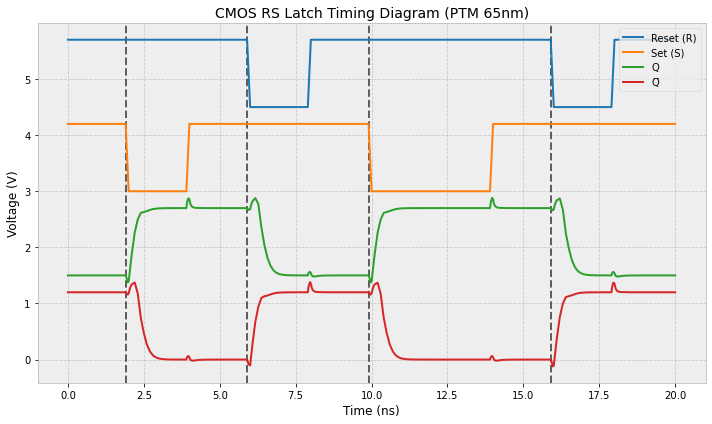

In [7]:
# ============================================================
# Waveform Visualization
# ============================================================
# Plot signals with vertical offset to improve readability.
# This format is standard for digital timing diagrams.
# ============================================================
time = analysis.time

plt.figure(figsize=(10, 6))

plt.title("CMOS RS Latch Timing Diagram (PTM 65nm)", fontsize=14)

# Plot the start of state changes
plt.axvline(1.90, c="k", ls="--", alpha=.6)
plt.axvline(5.90, c="k", ls="--", alpha=.6)
plt.axvline(9.90, c="k", ls="--", alpha=.6)
plt.axvline(15.9, c="k", ls="--", alpha=.6)

# Plot input and output signals with vertical offset
plt.plot(time * 1e9, np.array(analysis["vr"]) + 4.5, label="Reset (R)")
plt.plot(time * 1e9, np.array(analysis["vs"]) + 3.0, label="Set (S)")
plt.plot(time * 1e9, np.array(analysis["q"])  + 1.5, label="Q")
plt.plot(time * 1e9, np.array(analysis["q_bar"]),    label="Q̅")

plt.xlabel("Time (ns)")
plt.ylabel("Voltage (V)")

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

```{warning}
Il est possible de voir que la table de vérité est inversé contrairement a se qui a été montré dans la premiètre table de vérité : [](#Table_de_verite_d_une_bascule_RS). Il est possible d'écrire une nouvelle table de vérité à partri du chronograme présenté dans la partie précédente [](#Table_de_verite_d_une_bascule_RS_inverser). 

Donc cette fois ce n'est pas sur une valeur haute que la bascule s'active, mais sur une valeur basse. C'est lorsque la $R$ ou $S$ passe de 1 à 0 que le système s'active. 

Un autre point important de cela est que la valeur impossible n'est plus $R=1$ et $S=1$ mais l'inverse donc que les deux valeurs valent 0 ($S = R = 0$). 


```{table} Truth table of an RS latch inverse
:name: Table_de_verite_d_une_bascule_RS_inverser
:align: center
| $S$ | $R$ |     $Q$      |     $\bar{Q}$   |
| --- | --- | ------------ | --------------- |
|  1  |  1  |  $Q_{n-1}$   | $\bar{Q}_{n-1}$ |
|  1  |  0  |       0      |        1        |
|  0  |  1  |       1      |        0        |
|  0  |  0  |  undefined   |    undefined    |
```

Un point important a noté est que le système s'active des que les valeurs commence a baisser. Cela peut poser un problème s'il y a un peu de bruit sur les lignes. Pour résoudre se type de problème, il faut rajouter un trigger de smith en entrée afin d'activé le système que lorsque la valeur dépasse un certain seuil. Mais en contre partie, le temps de monté peut être un peu plus long.

#### Caracterisation (NAND Gates)

Dans cette partie, l'objectif est de voir comment se comporte le circuit est les différents paramètres qu'il est possible de regarder sur un circuit RS. les paramètres que l'on va regarder sont les suivants :
* propagation delay
* temps de monté du système
* temps de descante du circuit
* consommation du circuit
* bruit de sécurité

Tout d'abord, l'objectif est de regarder la propagration delay 

##### **Propagation delay**

Pour rappel l'objectif est de regarder deux paramètres qui sont $t_{PHL}$ et $t_{PLH}$. 

* $t_{PHL}$ correspond au temps de monté, le temps entre lorsque l'entrée dépasse 50% de la valeur final et le temps lorsque la valeur final atteint cette valeur de 50% aussi.
* $t_{PLH}$ cela correspond à la même chose que la valeur $t_{PHL}$, mais cette fois pour le temps de descante.

In [8]:
# ============================================================
# Simulator Configuration
# ============================================================
# Configure operating conditions and initial states.
# Initial conditions help avoid metastability at simulation start.
# ============================================================
simulator = circuit.simulator(
    temperature=25,           # Operating temperature (°C)
    nominal_temperature=25    # Model nominal temperature (°C)
)

# Define initial node voltages
simulator.initial_condition(
    # Inputs initialized in HOLD state
    vs    = VDD @ u_V,
    vr    = VDD @ u_V,
    # Define initial stored state
    q     = 0   @ u_V,
    q_bar = VDD @ u_V,
)

# ============================================================
# Transient Analysis
# ============================================================
# This analysis computes circuit behavior over time.
#
# step_time:
#   Simulation resolution (smaller = more accurate)
#
# end_time:
#   Total simulation duration
# ============================================================

analysis = simulator.transient(
    step_time = 0.02 @ u_ns,
    end_time  = 7.5 @ u_ns,
)

In [9]:
def find_crossings(time, signal, threshold):
    """
    Find all time points where signal crosses a given threshold.

    Uses linear interpolation for high precision.

    Parameters
    ----------
    time : array
        Time vector

    signal : array
        Signal voltage vector

    threshold : float
        Threshold voltage (example: 0.5 * VDD)

    Returns
    -------
    crossings : list
        List of crossing times
    """

    crossings = []

    for i in range(len(signal) - 1):

        v1 = signal[i]
        v2 = signal[i+1]
        # Check if threshold crossing occurs
        if (v1 - threshold) * (v2 - threshold) < 0:

            t1 = time[i]
            t2 = time[i+1]

            # Linear interpolation
            crossing_time = t1 + (threshold - v1) * (t2 - t1) / (v2 - v1)
            #crossing_time = (t1 + t2) / 2
            crossing_time = float(crossing_time)
            crossings.append(crossing_time)

    return np.array(crossings)

In [10]:
# ============================================================
# Propagation delay extraction at 50% VDD threshold
# ============================================================

# Define threshold voltage (50% of supply voltage)
threshold = VDD / 2

# Convert signals to NumPy arrays for faster processing
time         = np.array(analysis.time)
vr_signal    = np.array(analysis["vr"])
vs_signal    = np.array(analysis["vs"])
q_signal     = np.array(analysis["q"])
q_bar_signal = np.array(analysis["q_bar"])

# Compute propagation delay crossing times
vr_propagation_delay    = find_crossings(time, vr_signal, threshold)
vs_propagation_delay    = find_crossings(time, vs_signal, threshold)
q_propagation_delay     = find_crossings(time, q_signal, threshold)
q_bar_propagation_delay = find_crossings(time, q_bar_signal, threshold)

# ============================================================
# Summary output (optional, recommended for debugging)
# ============================================================

print("Propagation delay crossing times (50% VDD threshold)")
print("====================================================")
print(f"VR crossings    : {vr_propagation_delay}")
print(f"VS crossings    : {vs_propagation_delay}")
print(f"Q crossings     : {q_propagation_delay}")
print(f"Q̅ crossings    : {q_bar_propagation_delay}")

Propagation delay crossing times (50% VDD threshold)
VR crossings    : [5.95e-09]
VS crossings    : [1.95e-09 3.95e-09]
Q crossings     : [2.15303230e-09 6.44460974e-09]
Q̅ crossings    : [2.44540949e-09 6.15303503e-09]


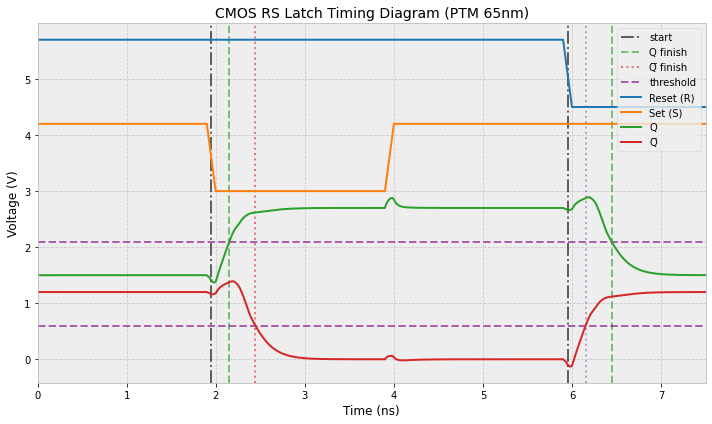

In [11]:
# ============================================================
# Waveform Visualization
# ============================================================
# Plot signals with vertical offset to improve readability.
# This format is standard for digital timing diagrams.
# ============================================================
time = analysis.time

plt.figure(figsize=(10, 6))

plt.title("CMOS RS Latch Timing Diagram (PTM 65nm)", fontsize=14)

# Plot the start of state changes
plt.axvline(vs_propagation_delay[0]*1e9, c="k", ls="-.", alpha=.6, label="start")
plt.axvline(vr_propagation_delay[0]*1e9, c="k", ls="-.", alpha=.6)
plt.axvline(q_propagation_delay[0]*1e9, c="C02", ls="--", alpha=.6, label="Q finish")
plt.axvline(q_propagation_delay[1]*1e9, c="C02", ls="--", alpha=.6)
plt.axvline(q_bar_propagation_delay[0]*1e9, c="C03", ls=":", alpha=.6, label="Q̅ finish")
plt.axvline(q_bar_propagation_delay[1]*1e9, c="C04", ls=":", alpha=.6)

# 50% VDD
plt.axhline(VDD/2,     c="purple", ls="--", alpha=.6, label="threshold")
plt.axhline(VDD/2+1.5, c="purple", ls="--", alpha=.6,)

# Plot input and output signals with vertical offset
plt.plot(time * 1e9, np.array(analysis["vr"]) + 4.5, label="Reset (R)")
plt.plot(time * 1e9, np.array(analysis["vs"]) + 3.0, label="Set (S)")
plt.plot(time * 1e9, np.array(analysis["q"])  + 1.5, label="Q")
plt.plot(time * 1e9, np.array(analysis["q_bar"]),    label="Q̅")

plt.xlabel("Time (ns)")
plt.ylabel("Voltage (V)")
plt.xlim(0, 7.5)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

Juste avec cette visualisation graphique il est possible de dire que les temps de charge sont plus rapide que les temps de décharge. L'autre point important et que les delay de propagation sont similaire pour la sortie $Q$ et la sortie $\bar{Q}$. Dans la prochaine partie, cette fois l'objectif est de caractériser plus finement ces temps de monté.

In [12]:
# ============================================================
# Propagation delaye
# ============================================================

# ---- T PHL
Tphl_Q     = q_propagation_delay[0] - vs_propagation_delay[0]
Tphl_Q_bar = q_bar_propagation_delay[1] - vr_propagation_delay[0]

# ---- T PLH
Tplh_Q     = q_propagation_delay[1] - vr_propagation_delay[0]
Tplh_Q_bar = q_bar_propagation_delay[0] - vs_propagation_delay[0]

print("Visualisation des delay de propagation")
print("======================================")
print("* Pour Q")
print(f"- T PHL : {Tphl_Q*1e9:.2f} ns")
print(f"- T PLH : {Tplh_Q*1e9:.2f} ns")
print("* Pour Q̅")
print(f"- T PHL : {Tphl_Q_bar*1e9:.2f} ns")
print(f"- T PLH : {Tplh_Q_bar*1e9:.2f} ns")

Visualisation des delay de propagation
* Pour Q
- T PHL : 0.20 ns
- T PLH : 0.49 ns
* Pour Q̅
- T PHL : 0.20 ns
- T PLH : 0.50 ns


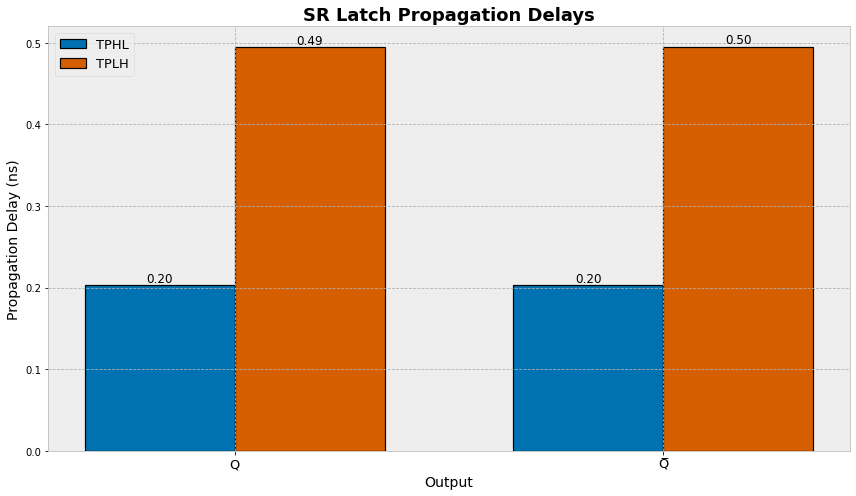

In [13]:
# Correct data
Tphl = [Tphl_Q*1e9, Tphl_Q_bar*1e9]
Tplh = [Tplh_Q*1e9, Tplh_Q_bar*1e9]

labels = ['Q', 'Q̅']

# Bar parameters
barWidth = 0.35
x = np.arange(len(labels))

# Professional scientific colors (colorblind-friendly)
color_tphl = "#0072B2"   # scientific blue
color_tplh = "#D55E00"   # scientific orange

# Create figure
fig, ax = plt.subplots()

# Plot bars (side-by-side, no overlap)
bars1 = ax.bar(x - barWidth/2, Tphl,
               width=barWidth,
               color=color_tphl,
               edgecolor='black',
               linewidth=1.2,
               label="TPHL")

bars2 = ax.bar(x + barWidth/2, Tplh,
               width=barWidth,
               color=color_tplh,
               edgecolor='black',
               linewidth=1.2,
               label="TPLH")

# Labels and title
ax.set_xlabel("Output", fontsize=14)
ax.set_ylabel("Propagation Delay (ns)", fontsize=14)
ax.set_title("SR Latch Propagation Delays", fontsize=18, fontweight='bold')

# X ticks
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13)

# Legend
ax.legend(fontsize=13)

# Function to display values on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                height,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=12)

add_labels(bars1)
add_labels(bars2)

# Improve layout
plt.tight_layout()

plt.show()

Grâce a se graphique il est possible de voir facilement que les deux sortie $Q$ et $\bar{Q}$ ont les mêmes temps de sorties. Cependant il y a une vrai différence entre le temps de charge et de décharge. Le temps de charge est environs plus de deux fois plus long que le temps de décharge qui est plus rapide. Dans la prochaine partie, l'objectif est de voir la différence et voir si cela est toujours le cas avec le temps de monté et le temps de descante.

##### **Temps de monté 10% - 90%**

L'ojectif de cette partie est de voir plus globalement comment se comporte le système sur le temps de monté. en regardant plus spéciquement la charge et la décharge. Cette partie se concentre uniquement sur $Q$ car dans la partie précédente il a été montré que $Q$ et $\bar{Q}$ sont identique sur le temps de monté et sur le temps de descante.

In [14]:
# ============================================================
# Timing Characterization: Rise and Fall Time Measurement
# ============================================================
#
# Objective:
#   Measure 10%–90% rise time (tr) and fall time (tf)
#   for Q and Q_bar signals of the RS latch.
#
# Method:
#   - Extract region of interest from transient simulation
#   - Detect first crossing at 10% VDD
#   - Detect first crossing at 90% VDD
#   - Compute rise/fall time
#
# Industry Standard:
#   Rise/Fall time = t(90%) - t(10%)
# ============================================================


# ============================================================
# 1. Define Analysis Window
# ============================================================
# Select region of interest to isolate the switching event.
# This avoids detecting unwanted transitions.
analysis_window = slice(80, 200)

In [15]:
# ============================================================
# 2. Extract Signals from Simulation
# ============================================================
time_window = np.array(time[analysis_window])
set_signal_window = (
    np.array(analysis["vs"])[analysis_window] * (-1) + VDD
)
q_signal_window = np.array(analysis["q"])[analysis_window]
q_bar_signal_window = (
    np.array(analysis["q_bar"])[analysis_window] * (-1) + VDD
)

In [16]:
# ============================================================
# 3. Define Voltage Thresholds (Industry Standard)
# ============================================================
threshold_10 = 0.1 * VDD
threshold_90 = 0.9 * VDD

In [17]:
# ============================================================
# 4. Detect Crossing Times
# ============================================================
# Find first time where signal exceeds threshold.
def first_crossing(time_vector, signal_vector, threshold):
    """
    Return first time at which signal exceeds given threshold.
    """
    indices = np.where(signal_vector > threshold)[0]
    return time_vector[indices[0]]


# --- Rise Time for Q ---
t_q_10 = first_crossing(time_window, q_signal_window, threshold_10)
t_q_90 = first_crossing(time_window, q_signal_window, threshold_90)
rise_time = t_q_90 - t_q_10

# --- Fall Time for Q_bar ---
t_q_bar_10 = first_crossing(time_window, q_bar_signal_window, threshold_10)
t_q_bar_90 = first_crossing(time_window, q_bar_signal_window, threshold_90)
fall_time = t_q_bar_90 - t_q_bar_10

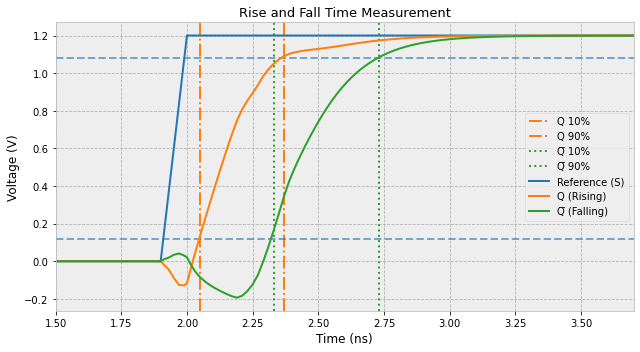

In [18]:
# ============================================================
# 5. Visualization
# ============================================================
plt.figure(figsize=(9, 5))
plt.title("Rise and Fall Time Measurement", fontsize=13)

# Vertical markers (10% and 90%)
plt.axvline(t_q_10 * 1e9, linestyle="-.", c="C01", label="Q 10%")
plt.axvline(t_q_90 * 1e9, linestyle="-.", c="C01", label="Q 90%")

plt.axvline(t_q_bar_10 * 1e9, linestyle=":", c="C02", label="Q̅ 10%")
plt.axvline(t_q_bar_90 * 1e9, linestyle=":", c="C02", label="Q̅ 90%")

# Horizontal thresholds
plt.axhline(threshold_10, linestyle="--", alpha=0.6)
plt.axhline(threshold_90, linestyle="--", alpha=0.6)

# Plot signals
plt.plot(time_window * 1e9, set_signal_window, label="Reference (S)")
plt.plot(time_window * 1e9, q_signal_window, label="Q (Rising)")
plt.plot(time_window * 1e9, q_bar_signal_window, label="Q̅ (Falling)")

plt.xlabel("Time (ns)")
plt.ylabel("Voltage (V)")
plt.xlim(1.5, 3.7)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# 6. Print Results
# ============================================================

print("Timing Characterization Results")
print("===============================")

print("\n--- Rise Time (Q) ---")
print(f"t_10%  = {t_q_10 * 1e9:.2f} ns")
print(f"t_90%  = {t_q_90 * 1e9:.2f} ns")
print(f"Rise Time (tr) = {rise_time * 1e9:.2f} ns")

print("\n--- Fall Time (Q̅) ---")
print(f"t_10%  = {t_q_bar_10 * 1e9:.2f} ns")
print(f"t_90%  = {t_q_bar_90 * 1e9:.2f} ns")
print(f"Fall Time (tf) = {fall_time * 1e9:.2f} ns")

print("\n--- Transition Start Offset ---")
print(
    f"Δt (Q̅_10% - Q_10%) = {(t_q_bar_10 - t_q_10) * 1e9:.2f} ns"
)

Timing Characterization Results

--- Rise Time (Q) ---
t_10%  = 2.05 ns
t_90%  = 2.37 ns
Rise Time (tr) = 0.32 ns

--- Fall Time (Q̅) ---
t_10%  = 2.33 ns
t_90%  = 2.73 ns
Fall Time (tf) = 0.40 ns

--- Transition Start Offset ---
Δt (Q̅_10% - Q_10%) = 0.28 ns


Tout d'abord, le temps de monté et le temps de descante sont dans les même ordre de grandeur environs 320 ps et 400 ps. Cependant, le temps de monté commence beaucoup plus tard, cela est du faite qu'il y a toute une partie décroissance dans la première partie du signal qui reparte largement le commencement du temps de monté, cette différence de temps est de 280 ps. 

```{note}
Je ne sais pas comment réduire se toutes cette décroissance, mais en rajoutant des capacité cela doit être réglable.
```

#### Simulation (NOR Gates)

In [20]:
class NOR(SubCircuit):
    """
    CMOS 2-Input NOR Gate – Transistor-Level Implementation

    Logic Function
    --------------
        Y = NOT (A OR B)

    Architecture
    ------------
    - Pull-Up Network (PUN):  PMOS transistors in series
    - Pull-Down Network (PDN): NMOS transistors in parallel

    External Nodes
    --------------
    A   : Input A
    B   : Input B
    Y   : Output
    VDD : Power supply
    """

    # External interface definition
    __nodes__ = ('A', 'B', 'Y', 'VDD')

    def __init__(self, name: str):
        """
        Initialize the CMOS NOR gate subcircuit.

        Parameters
        ----------
        name : str
            Unique identifier for this subcircuit instance.
        """

        # Initialize parent SubCircuit
        super().__init__(name, *self.__nodes__)

        # ============================================================
        # Internal Node Definition
        # ============================================================
        # Intermediate node for series PMOS connection
        node_pmos_series = 'node_pmos_series'

        # ============================================================
        # Pull-Up Network (PUN) – PMOS in Series
        # ============================================================
        # Function:
        # Output is pulled HIGH only when BOTH inputs are LOW.
        #
        # Electrical behavior:
        # PMOS conducts when Gate = LOW.
        # Series configuration implements NOR logic.
        #

        # PMOS transistor controlled by input A
        self.MOSFET(
            1,
            node_pmos_series,   # Drain
            'A',                # Gate
            'VDD',              # Source
            'VDD',              # Bulk
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5 @ u_um
        )

        # PMOS transistor controlled by input B
        self.MOSFET(
            2,
            'Y',                # Drain (output)
            'B',                # Gate
            node_pmos_series,   # Source
            'VDD',              # Bulk
            model='ptm65nm_pmos',
            l=0.35 @ u_um,
            w=0.5 @ u_um
        )

        # ============================================================
        # Pull-Down Network (PDN) – NMOS in Parallel
        # ============================================================
        # Function:
        # Output is pulled LOW if ANY input is HIGH.
        #
        # Electrical behavior:
        # NMOS conducts when Gate = HIGH.
        # Parallel configuration implements NOR logic.
        #

        # NMOS transistor controlled by input A
        self.MOSFET(
            3,
            'Y',                # Drain
            'A',                # Gate
            circuit.gnd,        # Source
            circuit.gnd,        # Bulk
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.1 @ u_um
        )

        # NMOS transistor controlled by input B
        self.MOSFET(
            4,
            'Y',
            'B',
            circuit.gnd,
            circuit.gnd,
            model='ptm65nm_nmos',
            l=0.35 @ u_um,
            w=0.1 @ u_um
        )

In [21]:
class RS_NOR(SubCircuit):
    """
    CMOS RS Latch – NOR-Based Implementation (Active-HIGH)

    Description
    -----------
    Bistable latch constructed using two cross-coupled NOR gates.

    Logic Characteristics
    ---------------------
    - Inputs are ACTIVE HIGH
    - S = 1  -> Set   (Q = 1)
    - R = 1  -> Reset (Q = 0)
    - S = R = 0 -> Hold previous state
    - S = R = 1 -> Forbidden / metastable condition

    External Nodes
    --------------
    R     : Reset input (active HIGH)
    S     : Set input   (active HIGH)
    Q     : Output
    Q_bar : Complementary output
    VDD   : Power supply
    """

    # External interface definition
    __nodes__ = ('R', 'S', 'Q', 'Q_bar', 'VDD')

    def __init__(self, name: str):
        """
        Initialize the NOR-based RS latch.

        Parameters
        ----------
        name : str
            Unique identifier of the subcircuit instance.
        """

        # Initialize parent class
        super().__init__(name, *self.__nodes__)

        # ============================================================
        # Cross-Coupled NOR Structure
        # ============================================================
        #
        # Structure:
        #
        #        +--------+          +--------+
        #   S -->|        |          |        |<-- R
        #        |  NOR   |---- Q ---|  NOR   |
        #        |        |          |        |
        #        +--------+          +--------+
        #              ^                  |
        #              |                  v
        #            Q_bar <--------------
        #
        # Feedback ensures bistable behavior.
        # ============================================================

        # ------------------------------------------------------------
        # First NOR Gate
        # Inputs : S, Q
        # Output : Q_bar
        # ------------------------------------------------------------
        self.X(
            'NOR_STAGE_1',
            'NOR',
            'S',        # External Set input
            'Q',        # Feedback from Q
            'Q_bar',    # Output
            'VDD'
        )

        # ------------------------------------------------------------
        # Second NOR Gate
        # Inputs : R, Q_bar
        # Output : Q
        # ------------------------------------------------------------
        self.X(
            'NOR_STAGE_2',
            'NOR',
            'R',        # External Reset input
            'Q_bar',    # Feedback from Q_bar
            'Q',        # Output
            'VDD'
        )

In [22]:
# ============================================================
# CMOS RS Latch – NOR-Based Architecture
# Technology: PTM 65nm Bulk CMOS
#
# Description:
#   Transient simulation testbench for an active-HIGH
#   RS latch implemented using cross-coupled NOR gates.
#
# Objectives:
#   - Validate SET behavior
#   - Validate RESET behavior
#   - Verify HOLD stability
#   - Exercise forbidden state (optional)
#
# Simulation Level:
#   Transistor-level (PTM 65nm models)
# ============================================================


# ============================================================
# 1. Circuit Initialization
# ============================================================

circuit = Circuit('CMOS RS Latch – NOR – PTM 65nm')


# ============================================================
# 2. Technology Model Inclusion
# ============================================================

circuit.include('lib/ptm_65nm_nmos_bulk.mod')
circuit.include('lib/ptm_65nm_pmos_bulk.mod')


# ============================================================
# 3. Subcircuit Registration
# ============================================================

circuit.subcircuit(NOR('NOR'))
circuit.subcircuit(RS_NOR('RS_NOR'))


# ============================================================
# 4. Power Supply Definition
# ============================================================

VDD = 1.2  # Nominal supply for 65nm node

circuit.V(
    'VDD_SRC',
    'vdd',
    circuit.gnd,
    VDD
)


# ============================================================
# 5. Input Stimulus Definition (Active HIGH)
# ============================================================
# NOR-based RS latch:
#   S = 1 → SET
#   R = 1 → RESET
# ============================================================


# ------------------------------------------------------------
# 5.1 Reset Input (R)
# ------------------------------------------------------------

reset_waveform = [
    # Initial HOLD
    (0.0  @ u_ns, 0 @ u_V),
    (5.9  @ u_ns, 0 @ u_V),

    # RESET pulse
    (6.0  @ u_ns, VDD @ u_V),
    (7.9  @ u_ns, VDD @ u_V),

    # HOLD
    (8.0  @ u_ns, 0 @ u_V),
    (15.9 @ u_ns, 0 @ u_V),

    # Second RESET pulse
    (16.0 @ u_ns, VDD @ u_V),
    (17.9 @ u_ns, VDD @ u_V),

    # Final HOLD
    (18.0 @ u_ns, 0 @ u_V),
]

circuit.PieceWiseLinearVoltageSource(
    'RESET_SRC',
    'node_reset',
    circuit.gnd,
    values=reset_waveform
)


# ------------------------------------------------------------
# 5.2 Set Input (S)
# ------------------------------------------------------------

set_waveform = [
    # Initial HOLD
    (0.0  @ u_ns, 0 @ u_V),
    (1.9  @ u_ns, 0 @ u_V),

    # SET pulse
    (2.0  @ u_ns, VDD @ u_V),
    (3.9  @ u_ns, VDD @ u_V),

    # HOLD
    (4.0  @ u_ns, 0 @ u_V),
    (9.9  @ u_ns, 0 @ u_V),

    # Second SET pulse
    (10.0 @ u_ns, VDD @ u_V),
    (12.0 @ u_ns, VDD @ u_V),

    # Final HOLD
    (12.1 @ u_ns, 0 @ u_V),
    (18.0 @ u_ns, 0 @ u_V),
]

circuit.PieceWiseLinearVoltageSource(
    'SET_SRC',
    'node_set',
    circuit.gnd,
    values=set_waveform
)


# ============================================================
# 6. RS Latch Instantiation
# ============================================================
circuit.X(
    'X_RS_LATCH', 
    'RS_NOR', 
    'node_reset',   # R input
    'node_set',     # S input
    'q',            # Q output
    'q_bar',        # Complementary output 
    'vdd'
);

In [23]:
# ============================================================
# Simulator Configuration
# ============================================================
# Configure operating conditions and initial states.
# Initial conditions help avoid metastability at simulation start.
# ============================================================
simulator = circuit.simulator(
    temperature=25,           # Operating temperature (°C)
    nominal_temperature=25    # Model nominal temperature (°C)
)

# Define initial node voltages
simulator.initial_condition(
    # Inputs initialized in HOLD state
    node_set    = VDD @ u_V,
    node_reset    = VDD @ u_V,
    # Define initial stored state
    q     = 0   @ u_V,
    q_bar = VDD @ u_V,
)

# ============================================================
# Transient Analysis
# ============================================================
# This analysis computes circuit behavior over time.
#
# step_time:
#   Simulation resolution (smaller = more accurate)
#
# end_time:
#   Total simulation duration
# ============================================================

analysis = simulator.transient(
    step_time = .1 @ u_ns,
    end_time  = 20 @ u_ns,
)

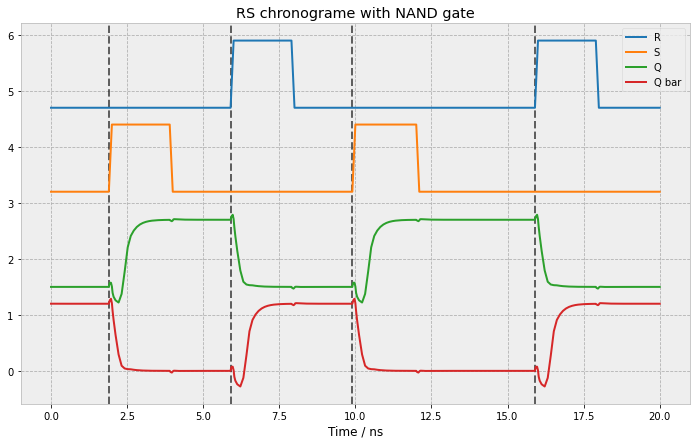

In [24]:
time = analysis.time

plt.figure()
plt.title("RS chronograme with NAND gate")

plt.axvline(1.90, c="k", ls="--", alpha=.6)
plt.axvline(5.90, c="k", ls="--", alpha=.6)
plt.axvline(9.90, c="k", ls="--", alpha=.6)
plt.axvline(15.9, c="k", ls="--", alpha=.6)


plt.plot(time*1e9, np.array(analysis["node_reset"])+4.7, label="R")
plt.plot(time*1e9, np.array(analysis["node_set"])+3.2, label="S")
plt.plot(time*1e9, np.array(analysis["q"])+1.5,  label="Q")
plt.plot(time*1e9, np.array(analysis["q_bar"]),  label="Q̅")
plt.xlabel("Time / ns")
plt.legend()
plt.show()

Il est possible de voir que cette fois la valeur correspond parfaitement à la valeur du tableau de vérité [](#Table_de_verite_d_une_bascule_RS) présenté dans sur le chronogramme. Il y a toujours les petit pics qui sont présent lors d'un changement de valeur cela est normal il est possible de corriger cela avec des capacité, seulement cela risque d'augmenter le temps de monté. Le temps de monté n'est pas négligeable dans notre cas. Un autre point important est que le circuit est très sensible des qu'un des circuit commence à monté alors il s'active, ainsi s'il y a du bruit dans le système. Cela peut poser un certain nombre de problème. 

### Synthcronous RS Latch

#### Presentation des circuit

Dans cette partie, l'objectif cette fois et de faire la même chose que dans la partie précédente avec des portes logiques, mais cette fois l'objectif est d'avoir une modification de la valeur que sur le front montant de l'horloge. Le montage électronique est quasiment le même qu'avec un montage asynchrone, juste il faut rajouter soit deux portes NAND ou deux portes NOR qui permettent de relier les entrées R et S avec l'entrée H, le montage est représenté sur la [](#RS_synchrone_porte_logique)

```{figure} ./images/RS_synchrone_porte_logique.svg
:name: RS_synchrone_porte_logique
:align: center
:width: 500px

Different logic-gate implementations of an synchronous RS flip-flop
```

Il est important de noté que comme précédement

#### Simulation (NAND)

In [60]:
# ============================================================
# CMOS RS
# Technology: PTM 65 nm
# ============================================================

# Create a new circuit for each input combination
circuit = Circuit('RS with NAND gate')

# ============================================================
# Model Libraries
# Include NMOS, PMOS transistor models
# Include NAND with transistor models
# Include RS with NAND gate
# ============================================================

# Include transistor models
circuit.include('lib/ptm_65nm_nmos_bulk.mod')
circuit.include('lib/ptm_65nm_pmos_bulk.mod')

# Include internal model
circuit.subcircuit(NAND('NAND'))
circuit.subcircuit(RS_NAND('RS_NAND'))

# ============================================================
# Power Supply Definition
# ============================================================

# Supply voltage
VDD = 1.2

# DC power supply (VDD)
circuit.V('dd', 'vdd', circuit.gnd, VDD)

# ============================================================
# Input Signal Definitions
# Two pulse voltage sources are used to test all logic states
# ============================================================

step = 2 @ u_ns

circuit.PulseVoltageSource(
    'H',
    'vh',
    circuit.gnd,
    0 @ u_V, VDD @ u_V,
    pulse_width = 1.4 @ u_ns,
    period = 2.8 @ u_ns
)

# ------------------------------------------------------------
# 5.2 Reset Input (R) – Active LOW (NAND-based latch)
# ------------------------------------------------------------
reset_waveform = [
    # Init HOLD
    (0.0 @ u_ns,  0 @ u_V),
    (5.9 @ u_ns,  0 @ u_V),

    # RESET pulse
    (6.0 @ u_ns,  VDD @ u_V),
    (7.9 @ u_ns,  VDD @ u_V),

    # HOLD
    (8.0 @ u_ns,  0 @ u_V),
    (15.9 @ u_ns, 0 @ u_V),

    # RESET pulse
    (16 @ u_ns,   VDD @ u_V),
    (17.9 @ u_ns, VDD @ u_V),

    # HOLD
    (18 @ u_ns,   0 @ u_V),
]
circuit.PieceWiseLinearVoltageSource(
    'RESET_SRC',
    'vr',
    circuit.gnd,
    values=reset_waveform,
)

# ------------------------------------------------------------
# 5.3 Set Input (S) – Active LOW (NAND-based latch)
# ------------------------------------------------------------
set_waveform = [
    # Init HOLD
    (0.0  @ u_ns, 0 @ u_V),
    (1.9  @ u_ns, 0 @ u_V),

    # SET pulse
    (2.0  @ u_ns, VDD @ u_V),
    (3.9  @ u_ns, VDD @ u_V),

    # HOLD
    (4.0  @ u_ns, 0 @ u_V),
    (9.9 @ u_ns,  0 @ u_V),

    # SET pulse
    (10  @ u_ns,  VDD @ u_V),
    (13.9 @ u_ns, VDD @ u_V),

    # Final HOLD
    (14 @ u_ns,   0 @ u_V),
]
circuit.PieceWiseLinearVoltageSource(
    'SET_SRC',
    'vs',
    circuit.gnd,
    values= set_waveform,
)

# ============================================================
# 6. Input Synchronization Stage
# ============================================================
# R_sync  = NAND(R_raw, H)
# S_sync  = NAND(S_raw, H)
#
# When H = 0 → outputs forced HIGH (inactive)
# When H = 1 → raw signals propagate
# ============================================================
circuit.X(
    'NAND_SYNC_R', 
    'NAND', 
    'vr', 
    'vh', 
    'vr_sync', 
    'vdd'
)
circuit.X(
    'NAND_SYNC_S', 
    'NAND', 
    'vs', 
    'vh', 
    'vs_sync', 
    'vdd'
)

# ============================================================
# 7. RS Latch Core Instantiation
# ============================================================
circuit.X(
    'X_RS_CORE',
    'RS_NAND', 
    'vr_sync', 
    'vs_sync', 
    'q', 
    'q_bar', 
    'vdd');

In [61]:
# ============================================================
# Simulator Configuration
# ============================================================
# Configure operating conditions and initial states.
# Initial conditions help avoid metastability at simulation start.
# ============================================================
simulator = circuit.simulator(
    temperature=25,           # Operating temperature (°C)
    nominal_temperature=25    # Model nominal temperature (°C)
)

# Define initial node voltages
simulator.initial_condition(
    # Inputs initialized in HOLD state
    vs     = 0 @ u_V,  
    vr     = 0 @ u_V,
    vh     = 0 @ u_V,
    # Define initial stored state
    q      = 0 @ u_V,    # V(q) = 1.2 V
    q_bar  = VDD @ u_V,  # V(q_bar) = 0 V
)


# ============================================================
# Transient Analysis
# ============================================================
# This analysis computes circuit behavior over time.
#
# step_time:
#   Simulation resolution (smaller = more accurate)
#
# end_time:
#   Total simulation duration
# ============================================================
analysis = simulator.transient(
    step_time=0.1 @ u_ns,
    end_time=20 @ u_ns,
)

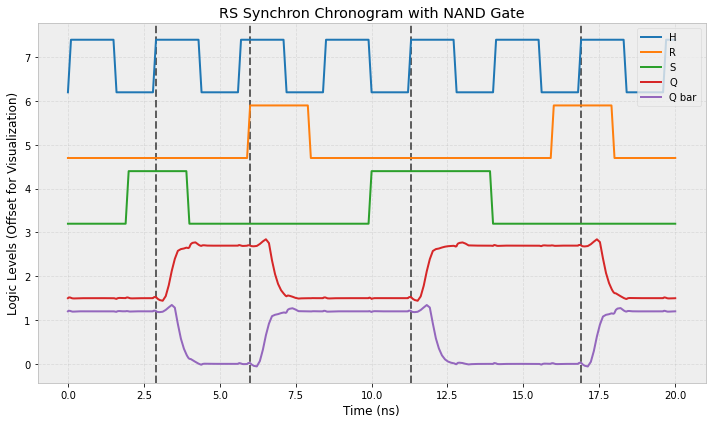

In [62]:
# ============================================================
# RS Synchronous Chronogram – NAND-Based Implementation
# ============================================================

# Extract simulation time vector
time = analysis.time

# ============================================================
# Plot Configuration
# ============================================================

plt.figure(figsize=(10, 6))
plt.title("RS Synchron Chronogram with NAND Gate")

# ------------------------------------------------------------
# Reference Vertical Markers (Key Transition Instants)
# ------------------------------------------------------------

plt.axvline(2.9,  c="k", ls="--", alpha=0.6)
plt.axvline(6.0,  c="k", ls="--", alpha=0.6)
plt.axvline(11.3, c="k", ls="--", alpha=0.6)
plt.axvline(16.9, c="k", ls="--", alpha=0.6)

# ------------------------------------------------------------
# Vertical Offsets for Readability
# (Prevents waveform overlap)
# ------------------------------------------------------------

offset_H     = 6.2
offset_R     = 4.7
offset_S     = 3.2
offset_Q     = 1.5
offset_Qbar  = 0.0

# ------------------------------------------------------------
# Waveform Plotting
# ------------------------------------------------------------

plt.plot(time * 1e9,
         np.array(analysis["vh"]) + offset_H,
         label="H")

plt.plot(time * 1e9,
         np.array(analysis["vr"]) + offset_R,
         label="R")

plt.plot(time * 1e9,
         np.array(analysis["vs"]) + offset_S,
         label="S")

plt.plot(time * 1e9,
         np.array(analysis["q"]) + offset_Q,
         label="Q")

plt.plot(time * 1e9,
         np.array(analysis["q_bar"]) + offset_Qbar,
         label="Q̅")

# ------------------------------------------------------------
# Axis & Legend
# ------------------------------------------------------------
plt.xlabel("Time (ns)")
plt.ylabel("Logic Levels (Offset for Visualization)")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

Il est possible de voir que la table de vérité est bien respecté [](#Truth_table_of_an_RS_flip-flop_with_NAND_gate). Ce qui est important de noté ici qu'il n'y a pas de notion de monté ou de notion de descante la ce qui est important est la valeur de la clock. Un autre point qui est important de noté est le temps de monté. Le temps de monté dans notre cas le temps de monté est long. C'est pour cela qu'il semble qu'il y a un décalage non négligeable entre le moment ou toutes les conditions sont respecté et le moment ou le circuit monte vraiment.

```{table} Truth table of an RS flip-flop with NAND gate
:name: Truth_table_of_an_RS_flip-flop_with_NAND_gate
:align: center
| $H$ | $S$ | $R$ |     $Q$      |     $\bar{Q}$   |
| --- | --- | --- | ------------ | --------------- |
|  0  |  X  |  X  |  $Q_{n-1}$   | $\bar{Q}_{n-1}$ |
|  X  |  0  |  0  |  $Q_{n-1}$   | $\bar{Q}_{n-1}$ |
|  1  |  1  |  0  |       1      |        0        |
|  1  |  0  |  1  |       0      |        1        |
|  1  |  1  |  1  |  undefined   |    undefined    |
```

Il y a encore un certain nombre de test qu'il est possible d'écrire comme cela a été fait précédement, mais cela ne va pas être fait sur cette partie.

#### Simulation (NOR)

Cette fois dans la prochaine partie, l'objectif est de faire le même type de circuit mais cette fois avec des portes NOR. Mais attention, l'activation se fait sur sur un niveau haut ce qui est l'inverse que ce qui a été fait dans la partie précédente.

In [78]:
# ============================================================
# CMOS RS Latch – NOR-Based Synchronous Architecture
# Technology: PTM 65 nm Bulk CMOS
#
# Description:
#   RS latch implemented with cross-coupled NOR gates.
#   Inputs R and S are synchronized through a gating signal H.
#
# Architecture:
#   Stage 1 : Input gating (NOR with H)
#   Stage 2 : RS_NOR core (bistable latch)
#
# Objectives:
#   - Validate synchronous SET / RESET behavior
#   - Observe propagation through gating stage
#   - Analyze timing behavior at transistor level
# ============================================================


# ============================================================
# 1. Circuit Initialization
# ============================================================
circuit = Circuit('RS with NAND gate')

# ============================================================
# 2. Model Libraries
# ============================================================

# PTM 65nm transistor models
circuit.include('lib/ptm_65nm_nmos_bulk.mod')
circuit.include('lib/ptm_65nm_pmos_bulk.mod')

# Internal subcircuits
circuit.subcircuit(NOR('NOR'))
circuit.subcircuit(RS_NOR('RS_NOR'))

# ============================================================
# Power Supply Definition
# ============================================================

# ============================================================
# 3. Power Supply Definition
# ============================================================

VDD = 1.2  # Nominal supply voltage (65nm node)

circuit.V(
    'dd',          # Source name (kept unchanged)
    'vdd',
    circuit.gnd,
    VDD
)

# ============================================================
# 4. Input Signal Definitions
# ============================================================

# ------------------------------------------------------------
# 4.1 Synchronization Signal H
# ------------------------------------------------------------
# Acts as an enable signal.
# When H = 0 → inputs propagate normally (NOR gating effect)
# When H = 1 → gating modifies input behavior
# ------------------------------------------------------------
circuit.PulseVoltageSource(
    'H',
    'vh',
    circuit.gnd,
    0 @ u_V, 
    VDD @ u_V,
    pulse_width = 1.7 @ u_ns,
    period      = 3.4 @ u_ns
)

# ------------------------------------------------------------
# 4.2 Reset Input R (Active HIGH for NOR-based latch)
# ------------------------------------------------------------
reset_waveform = [
    # Init HOLD
    (0.0 @ u_ns,  VDD @ u_V),
    (5.9 @ u_ns,  VDD @ u_V),

    # Reset pulse
    (6.0 @ u_ns,  0   @ u_V),
    (7.9 @ u_ns,  0   @ u_V),

    # Init HOLD
    (8.0 @ u_ns,  VDD @ u_V),
    (15.9 @ u_ns, VDD @ u_V),

    # Reset pulse
    (16 @ u_ns,   0 @ u_V),
    (17.9 @ u_ns, 0 @ u_V),

    # Final HOLD
    (18 @ u_ns,   VDD @ u_V),
]
circuit.PieceWiseLinearVoltageSource(
    'RESET_SRC',
    'vr',
    circuit.gnd,
    values=reset_waveform,
)

# ------------------------------------------------------------
# 4.3 Set Input S (Active HIGH for NOR-based latch)
# ------------------------------------------------------------
set_waveform = [
    # Init HOLD
    (0.0  @ u_ns, VDD @ u_V),
    (1.9  @ u_ns, VDD @ u_V),

    # Set pulse
    (2.0  @ u_ns, 0   @ u_V),
    (3.9  @ u_ns, 0   @ u_V),

    # Init HOLD
    (4.0  @ u_ns, VDD @ u_V),
    (9.9 @ u_ns,  VDD @ u_V),

    # Set pulse
    (10  @ u_ns,  0 @ u_V),
    (13.9 @ u_ns, 0 @ u_V),

    # Final HOLD
    (14 @ u_ns,   VDD @ u_V),
]
circuit.PieceWiseLinearVoltageSource(
    'SET_SRC',
    'vs',
    circuit.gnd,
    values= set_waveform,
)

# ============================================================
# 5. Input Synchronization Stage (NOR Gating)
# ============================================================
# vr_synchro = NOR(vr, vh)
# vs_synchro = NOR(vs, vh)
#
# This stage modifies R and S behavior based on H.
# ============================================================
circuit.X(
    'NOR_SYNC_R', 
    'NOR', 
    'vr', 
    'vh', 
    'vr_sync', 
    'vdd'
)

circuit.X(
    'NOR_SYNC_S', 
    'NOR', 
    'vs', 
    'vh', 
    'vs_sync', 
    'vdd'
)

# ============================================================
# 6. RS Latch Core
# ============================================================
circuit.X(
    'X_RS_CORE', 
    'RS_NOR', 
    'vr_sync', 
    'vs_sync', 
    'q', 
    'q_bar', 
    'vdd'
);

In [79]:
# ============================================================
# Simulator Configuration
# ============================================================
# Configure operating conditions and initial states.
# Initial conditions help avoid metastability at simulation start.
# ============================================================
simulator = circuit.simulator(
    temperature=25,           # Operating temperature (°C)
    nominal_temperature=25    # Model nominal temperature (°C)
)

# Define initial node voltages
simulator.initial_condition(
    # Inputs initialized in HOLD state
    vs     = VDD @ u_V,  
    vr     = VDD @ u_V,  
    # Define initial stored state
    q      = 0 @ u_V,  # V(q) = 1.2 V
    q_bar  = VDD @ u_V,  # V(q_bar) = 0 V
)


# ============================================================
# Transient Analysis
# ============================================================
# This analysis computes circuit behavior over time.
#
# step_time:
#   Simulation resolution (smaller = more accurate)
#
# end_time:
#   Total simulation duration
# ============================================================
analysis = simulator.transient(
    step_time = 0.1 @ u_ns,
    end_time  = 20 @ u_ns,
)

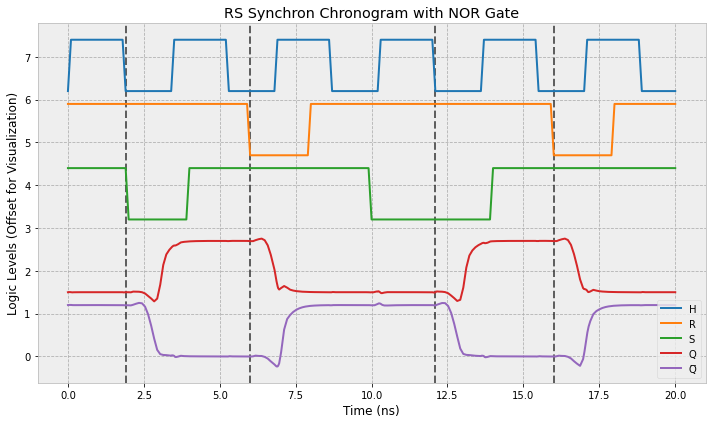

In [86]:
# ============================================================
# RS Synchronous Chronogram – NAND-Based Implementation
# ============================================================

# Extract simulation time vector
time = analysis.time

# ============================================================
# Plot Configuration
# ============================================================
plt.figure(figsize=(10, 6))
plt.title("RS Synchron Chronogram with NOR Gate")

# ------------------------------------------------------------
# Reference Vertical Markers (Key Transition Instants)
# ------------------------------------------------------------
plt.axvline(1.9,  c="k", ls="--", alpha=0.6)
plt.axvline(6.0,  c="k", ls="--", alpha=0.6)
plt.axvline(12.1, c="k", ls="--", alpha=0.6)
plt.axvline(16.0, c="k", ls="--", alpha=0.6)

# ------------------------------------------------------------
# Vertical Offsets for Readability
# (Prevents waveform overlap)
# ------------------------------------------------------------
offset_H     = 6.2
offset_R     = 4.7
offset_S     = 3.2
offset_Q     = 1.5
offset_Qbar  = 0.0

# ------------------------------------------------------------
# Waveform Plotting
# ------------------------------------------------------------
plt.plot(time*1e9, 
         np.array(analysis["vh"]) + offset_H, 
         label="H")
plt.plot(time*1e9, 
         np.array(analysis["vr"]) + offset_R, 
         label="R")
plt.plot(time*1e9, 
         np.array(analysis["vs"]) + offset_S, 
         label="S")
plt.plot(time*1e9, 
         np.array(analysis["q"]) + offset_Q,  
         label="Q")
plt.plot(time*1e9, 
         np.array(analysis["q_bar"])+offset_Qbar,  
         label="Q̅")

# ------------------------------------------------------------
# Axis & Legend
# ------------------------------------------------------------
plt.xlabel("Time (ns)")
plt.ylabel("Logic Levels (Offset for Visualization)")
plt.legend(loc="upper right")
plt.legend()

plt.tight_layout()
plt.show()

Il y a encore beaucoup de chose a dire sur ce type de circuit. Comme a faire un certain nombre de test. Mais pour l'instant, ce notebook ne pas plus loin dans la caractérisation de se type de circuit. Dans la prochaine partie, l'objectif est de faire la même chose, mais avec des transistors.

## CMOS

Maintenant, l'objectif est de voir comment consevoir une bascule RS avec des composant, CMOS. Dans les architecture qui ont été créer avec des portes logiques, il faut 8 transistors pour créer une portes RS asynchrone et à cela il faut rajouter 8 portes pour avoir le synchrone ce qui monte le système à 16 transistors CMOS. L'objectif de la prochaine partie est de voir s'il est possible de réduire ce nombre de transistors nécéssaire et donc réduire mécaniquement, le temps de monté du système, mais aussi l'énergie discipé dans le système. Tout 